In [1]:
# Ejecuta esto en una celda de código (es Python)
%load_ext rpy2.ipython

In [2]:
%%R
# 1. Instalar y cargar librerías necesarias
if (!require("pheatmap")) install.packages("pheatmap")
if (!require("ggplot2")) install.packages("ggplot2")
if (!require("dplyr")) install.packages("dplyr")
if (!require("tibble")) install.packages("tibble")

library(pheatmap)
library(ggplot2)
library(dplyr)
library(tibble)

# 2. Cargar el archivo normalizado
df <- read.csv("normalizado_con_simbolos.csv", check.names = FALSE, stringsAsFactors = FALSE)

# 3. Limpieza de datos (Manejo del formato de números con puntos: "1.184.867.254")
cols_signal <- grep("AVG_Signal", colnames(df), value = TRUE)

limpiar_numeros <- function(x) {
  # Eliminamos los puntos y convertimos a numérico
  num <- as.numeric(gsub("\\.", "", as.character(x)))
  # Transformación Log2 (sumamos 1 para evitar log(0))
  return(log2(num + 1))
}

df_clean <- df %>%
  mutate(across(all_of(cols_signal), limpiar_numeros)) %>%
  filter(!is.na(SYMBOL) & SYMBOL != "")

# 4. Colapsar por Gen (Promedio por SYMBOL)
matriz_genes <- df_clean %>%
  select(SYMBOL, all_of(cols_signal)) %>%
  group_by(SYMBOL) %>%
  summarise(across(everything(), mean, na.rm = TRUE)) %>%
  column_to_rownames("SYMBOL")

# 5. SEXADO AUTOMÁTICO
# Genes del cromosoma Y que mencionaste
genes_Y <- c("UTY", "KDM5D", "DDX3Y", "ZFY", "SRY")
genes_Y_presentes <- intersect(genes_Y, rownames(matriz_genes))

# Calculamos la señal media del cromosoma Y por muestra
signal_Y <- colMeans(matriz_genes[genes_Y_presentes, , drop=FALSE])

# Clasificación: Usamos la mediana como punto de corte
metadata <- data.frame(
  Sample = names(signal_Y),
  Sexo = ifelse(signal_Y > median(signal_Y), "Male (XY)", "Female (XX)")
)
rownames(metadata) <- metadata$Sample

# 6. GRÁFICO PCA
pca_res <- prcomp(t(matriz_genes), scale. = TRUE)
pca_df <- as.data.frame(pca_res$x)
pca_df$Sexo <- metadata$Sexo

pca_plot <- ggplot(pca_df, aes(x = PC1, y = PC2, color = Sexo)) +
  geom_point(size = 4) +
  theme_minimal() +
  labs(title = "PCA: Agrupación de Muestras por Sexo",
       x = paste0("PC1 (", round(summary(pca_res)$importance[2,1]*100, 1), "%)"),
       y = paste0("PC2 (", round(summary(pca_res)$importance[2,2]*100, 1), "%)"))

print(pca_plot)

# 7. HEATMAP DE GENES ESPECÍFICOS
genes_interes <- c("KDM6A", "KDM5C", "EIF2S3", "DDX3X", "SMC1A", "USP9X", "ZFX",
                   "UTY", "KDM5D", "DDX3Y", "ZFY", "SRY",
                   "SOX9", "AMH", "DMRT1")

genes_plot <- intersect(genes_interes, rownames(matriz_genes))
matriz_heatmap <- matriz_genes[genes_plot, ]

pheatmap(matriz_heatmap,
         annotation_col = metadata["Sexo"],
         scale = "row",
         main = "Heatmap: Genes Cromosómicos y de Desarrollo",
         color = colorRampPalette(c("navy", "white", "firebrick3"))(100))

# Guardar la tabla de resultados del sexado
write.csv(metadata, "resultado_sexado_muestras.csv", row.names = FALSE)

Loading required package: pheatmap
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/pheatmap_1.0.13.tar.gz'
Content type 'application/x-gzip' length 15162 bytes (14 KB)
downloaded 14 KB


The downloaded source packages are in
	‘/tmp/Rtmp1WYHPK/downloaded_packages’
Loading required package: ggplot2
Loading required package: dplyr

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

Loading required package: tibble
Error in file(file, "rt") : cannot open the connection
In addition: Warning messages:
1: In library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE,  :
  there is no package called ‘pheatmap’
2: In file(file, "rt") :
  cannot open file 'normalizado_con_simbolos.csv': No such file or directory
Error in file(file, "rt") : cannot op

RInterpreterError: Failed to parse and evaluate line '# 1. Instalar y cargar librerías necesarias\nif (!require("pheatmap")) install.packages("pheatmap")\nif (!require("ggplot2")) install.packages("ggplot2")\nif (!require("dplyr")) install.packages("dplyr")\nif (!require("tibble")) install.packages("tibble")\n\nlibrary(pheatmap)\nlibrary(ggplot2)\nlibrary(dplyr)\nlibrary(tibble)\n\n# 2. Cargar el archivo normalizado\ndf <- read.csv("normalizado_con_simbolos.csv", check.names = FALSE, stringsAsFactors = FALSE)\n\n# 3. Limpieza de datos (Manejo del formato de números con puntos: "1.184.867.254")\ncols_signal <- grep("AVG_Signal", colnames(df), value = TRUE)\n\nlimpiar_numeros <- function(x) {\n  # Eliminamos los puntos y convertimos a numérico\n  num <- as.numeric(gsub("\\\\.", "", as.character(x)))\n  # Transformación Log2 (sumamos 1 para evitar log(0))\n  return(log2(num + 1))\n}\n\ndf_clean <- df %>%\n  mutate(across(all_of(cols_signal), limpiar_numeros)) %>%\n  filter(!is.na(SYMBOL) 

Cargando archivo...
Procesando y transformando datos (Log2)...
Generando PCA...
Generando Heatmap...

--- PROCESO FINALIZADO ---
Archivos generados en la carpeta lateral:
1. PCA_Sexo_GSE25906.png
2. Heatmap_Genes_Sexo.png
3. clasificacion_sexo_final.csv


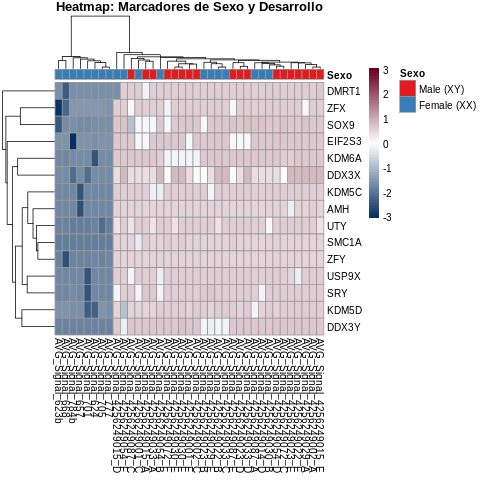

In [ ]:
%%R
# 1. INSTALACIÓN Y CARGA DE LIBRERÍAS
if (!require("pheatmap")) install.packages("pheatmap")
if (!require("ggplot2")) install.packages("ggplot2")
if (!require("dplyr")) install.packages("dplyr")
if (!require("tibble")) install.packages("tibble")

library(pheatmap)
library(ggplot2)
library(dplyr)
library(tibble)

# 2. CARGA DE DATOS
# Cargamos el archivo que ya tiene los símbolos de genes
cat("Cargando archivo...\n")
df <- read.csv("normalizado_con_simbolos.csv", check.names = FALSE, stringsAsFactors = FALSE)

# 3. LIMPIEZA Y TRANSFORMACIÓN
# Identificamos las columnas de expresión (AVG_Signal)
cols_signal <- grep("AVG_Signal", colnames(df), value = TRUE)

# Función para convertir formato "1.184.867.254" a número y aplicar Log2
limpiar_log2 <- function(x) {
  num <- as.numeric(gsub("\\.", "", as.character(x)))
  return(log2(num + 1))
}

cat("Procesando y transformando datos (Log2)...\n")
df_clean <- df %>%
  mutate(across(all_of(cols_signal), limpiar_log2)) %>%
  filter(!is.na(SYMBOL) & SYMBOL != "")

# Colapsamos por Gen (promedio de sondas si el gen se repite)
matriz_genes <- df_clean %>%
  select(SYMBOL, all_of(cols_signal)) %>%
  group_by(SYMBOL) %>%
  summarise(across(everything(), mean, na.rm = TRUE)) %>%
  column_to_rownames("SYMBOL")

# 4. CLASIFICACIÓN DE SEXO (SEXING)
# Genes marcadores del cromosoma Y
genes_Y <- c("UTY", "KDM5D", "DDX3Y", "ZFY", "SRY")
genes_Y_presentes <- intersect(genes_Y, rownames(matriz_genes))

# Calculamos la señal promedio de genes Y por muestra
signal_Y <- colMeans(matriz_genes[genes_Y_presentes, , drop=FALSE])

# Clasificamos usando la mediana como umbral
metadata <- data.frame(
  Sample = names(signal_Y),
  Sexo = ifelse(signal_Y > median(signal_Y), "Male (XY)", "Female (XX)")
)
rownames(metadata) <- metadata$Sample

# 5. GENERAR Y GUARDAR PCA (Imagen 1)
cat("Generando PCA...\n")
pca_res <- prcomp(t(matriz_genes), scale. = TRUE)
pca_df <- as.data.frame(pca_res$x)
pca_df$Sexo <- metadata$Sexo

pca_plot <- ggplot(pca_df, aes(x = PC1, y = PC2, color = Sexo)) +
  geom_point(size = 5, alpha = 0.8) +
  scale_color_manual(values = c("Male (XY)" = "#E41A1C", "Female (XX)" = "#377EB8")) +
  theme_minimal(base_size = 14) +
  labs(title = "PCA: Agrupación de Muestras por Sexo",
       subtitle = "Basado en expresión global (GSE25906)",
       x = paste0("PC1 (", round(summary(pca_res)$importance[2,1]*100, 1), "%)"),
       y = paste0("PC2 (", round(summary(pca_res)$importance[2,2]*100, 1), "%)"))

png("PCA_Sexo_GSE25906.png", width = 2500, height = 2000, res = 300)
print(pca_plot)
dev.off()

# 6. GENERAR Y GUARDAR HEATMAP (Imagen 2)
cat("Generando Heatmap...\n")
genes_interes <- c("KDM6A", "KDM5C", "EIF2S3", "DDX3X", "SMC1A", "USP9X", "ZFX", # Genes X
                   "UTY", "KDM5D", "DDX3Y", "ZFY", "SRY",                       # Genes Y
                   "SOX9", "AMH", "DMRT1")                                      # Desarrollo

genes_plot <- intersect(genes_interes, rownames(matriz_genes))
matriz_heatmap <- matriz_genes[genes_plot, ]

png("Heatmap_Genes_Sexo.png", width = 2500, height = 2200, res = 300)
pheatmap(matriz_heatmap,
         annotation_col = metadata["Sexo"],
         annotation_colors = list(Sexo = c("Male (XY)" = "#E41A1C", "Female (XX)" = "#377EB8")),
         scale = "row",
         clustering_distance_cols = "euclidean",
         main = "Heatmap: Marcadores de Sexo y Desarrollo",
         color = colorRampPalette(c("#053061", "white", "#67001f"))(100))
dev.off()

# 7. GUARDAR RESULTADOS DE TEXTO
write.csv(metadata, "clasificacion_sexo_final.csv", row.names = FALSE)

cat("\n--- PROCESO FINALIZADO ---\n")
cat("Archivos generados en la carpeta lateral:\n")
cat("1. PCA_Sexo_GSE25906.png\n")
cat("2. Heatmap_Genes_Sexo.png\n")
cat("3. clasificacion_sexo_final.csv\n")

Cargando archivo no normalizado...
Limpiando y transformando datos...
Genes restantes tras limpieza: 19697 
Calculando PCA...
Generando Heatmap...

¡Finalizado! Archivos guardados: PCA_NoNormalizado_Sexo.png y Heatmap_NoNormalizado_Sexo.png

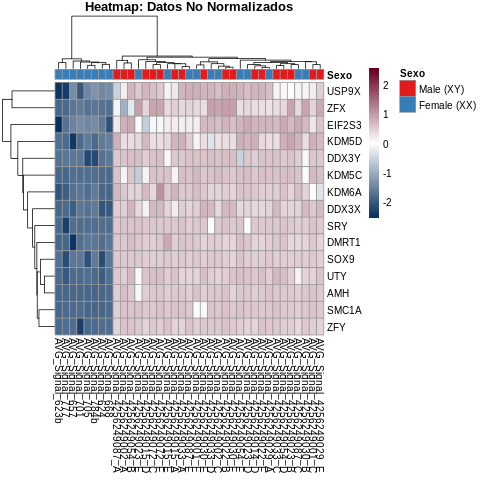

In [ ]:
%%R
# 1. CARGA DE LIBRERÍAS
if (!require("pheatmap")) install.packages("pheatmap")
if (!require("ggplot2")) install.packages("ggplot2")
if (!require("dplyr")) install.packages("dplyr")
if (!require("tibble")) install.packages("tibble")

library(pheatmap)
library(ggplot2)
library(dplyr)
library(tibble)

# 2. CARGA DE DATOS (Usando el archivo no normalizado)
cat("Cargando archivo no normalizado...\n")
df <- read.csv("no_normalizado_con_simbolos.csv", check.names = FALSE, stringsAsFactors = FALSE)

# 3. LIMPIEZA PROFUNDA
cols_signal <- grep("AVG_Signal", colnames(df), value = TRUE)

limpiar_log2 <- function(x) {
  # 1. Quitar puntos de miles
  x_clean <- gsub("\\.", "", as.character(x))
  # 2. Convertir a numérico (esto genera NAs si hay texto extraño)
  num <- as.numeric(x_clean)
  # 3. Log2 (usamos max(0, num) para evitar problemas con negativos o ceros)
  return(log2(num + 1))
}

cat("Limpiando y transformando datos...\n")
df_clean <- df %>%
  mutate(across(all_of(cols_signal), limpiar_log2)) %>%
  filter(!is.na(SYMBOL) & SYMBOL != "")

# Colapsar por Gen (Promedio por SYMBOL)
matriz_genes <- df_clean %>%
  select(SYMBOL, all_of(cols_signal)) %>%
  group_by(SYMBOL) %>%
  summarise(across(everything(), mean, na.rm = TRUE)) %>%
  column_to_rownames("SYMBOL")

# --- PASO CRÍTICO PARA EVITAR EL ERROR SVD ---
# 1. Eliminar filas que tengan CUALQUIER valor NA o Infinito
matriz_genes <- matriz_genes[complete.cases(matriz_genes), ]
matriz_genes <- matriz_genes[is.finite(rowSums(matriz_genes)), ]

# 2. Eliminar genes con varianza cero (todos los valores iguales)
# El PCA falla si un gen tiene el mismo valor en todas las muestras
varianzas <- apply(matriz_genes, 1, var)
matriz_genes <- matriz_genes[varianzas > 0, ]

cat(paste("Genes restantes tras limpieza:", nrow(matriz_genes), "\n"))

# 4. SEXADO AUTOMÁTICO
genes_Y <- c("UTY", "KDM5D", "DDX3Y", "ZFY", "SRY")
genes_Y_presentes <- intersect(genes_Y, rownames(matriz_genes))

signal_Y <- colMeans(matriz_genes[genes_Y_presentes, , drop=FALSE])
metadata <- data.frame(
  Sample = names(signal_Y),
  Sexo = ifelse(signal_Y > median(signal_Y, na.rm=TRUE), "Male (XY)", "Female (XX)")
)
rownames(metadata) <- metadata$Sample

# 5. GENERAR Y GUARDAR PCA (Imagen 1)
cat("Calculando PCA...\n")
# Usamos scale=TRUE para normalizar las magnitudes de los genes
pca_res <- prcomp(t(matriz_genes), scale. = TRUE)
pca_df <- as.data.frame(pca_res$x)
pca_df$Sexo <- metadata$Sexo

pca_plot <- ggplot(pca_df, aes(x = PC1, y = PC2, color = Sexo)) +
  geom_point(size = 5, alpha = 0.8) +
  scale_color_manual(values = c("Male (XY)" = "#E41A1C", "Female (XX)" = "#377EB8")) +
  theme_minimal(base_size = 14) +
  labs(title = "PCA: Datos No Normalizados (GSE25906)",
       subtitle = "Limpieza de NAs y Varianza Cero aplicada",
       x = paste0("PC1 (", round(summary(pca_res)$importance[2,1]*100, 1), "%)"),
       y = paste0("PC2 (", round(summary(pca_res)$importance[2,2]*100, 1), "%)"))

png("PCA_NoNormalizado_Sexo.png", width = 2500, height = 2000, res = 300)
print(pca_plot)
dev.off()

# 6. GENERAR Y GUARDAR HEATMAP (Imagen 2)
cat("Generando Heatmap...\n")
genes_interes <- c("KDM6A", "KDM5C", "EIF2S3", "DDX3X", "SMC1A", "USP9X", "ZFX",
                   "UTY", "KDM5D", "DDX3Y", "ZFY", "SRY",
                   "SOX9", "AMH", "DMRT1")

genes_plot <- intersect(genes_interes, rownames(matriz_genes))
matriz_heatmap <- matriz_genes[genes_plot, ]

png("Heatmap_NoNormalizado_Sexo.png", width = 2500, height = 2200, res = 300)
pheatmap(matriz_heatmap,
         annotation_col = metadata["Sexo"],
         annotation_colors = list(Sexo = c("Male (XY)" = "#E41A1C", "Female (XX)" = "#377EB8")),
         scale = "row",
         main = "Heatmap: Datos No Normalizados",
         color = colorRampPalette(c("#053061", "white", "#67001f"))(100))
dev.off()

write.csv(metadata, "sexado_no_normalizado.csv", row.names = FALSE)
cat("\n¡Finalizado! Archivos guardados: PCA_NoNormalizado_Sexo.png y Heatmap_NoNormalizado_Sexo.png")